In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/AAPL.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (10931, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [4]:
data = df.tail(500).copy().reset_index(drop=True)

x = np.arange(1, 501, dtype=float)
y = data["Close"].to_numpy(dtype=float)

print("Number of observations:", len(data))
print("Date range:", data["Date"].iloc[0], "to", data["Date"].iloc[-1])

data[["Date", "Close"]].head()

Number of observations: 500
Date range: 2022-04-27 to 2024-04-23


,Date,Close
0,2022-04-27,156.570007
1,2022-04-28,163.639999
2,2022-04-29,157.649994
3,2022-05-02,157.960007
4,2022-05-03,159.479996


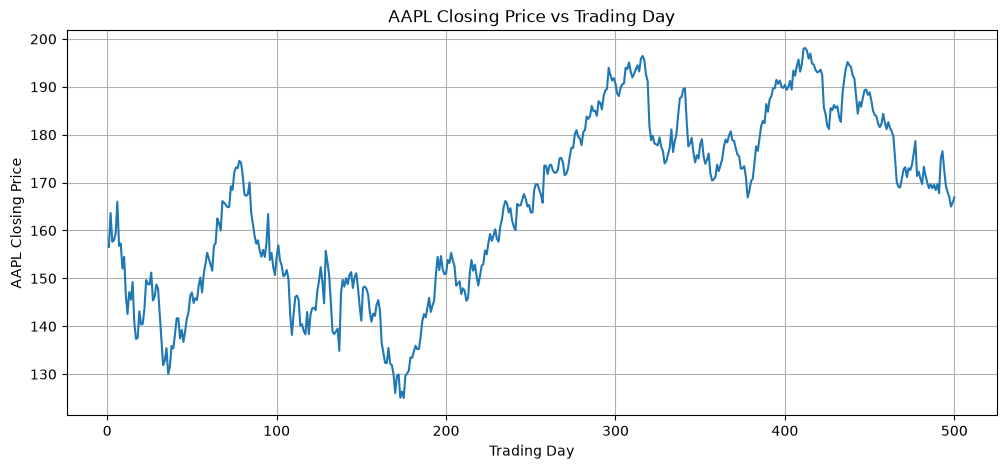

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(x, y)

plt.xlabel("Trading Day")
plt.ylabel("AAPL Closing Price")
plt.title("AAPL Closing Price vs Trading Day")

plt.grid()
plt.show()

## Lagrange Interpolation

The AAPL closing-price data is available at discrete trading-day points.

Lagrange interpolation is used to estimate the closing price at equally spaced points required for numerical integration.

To avoid using one very high-degree polynomial, local interpolation using nearby data points is used.

In [6]:
def lagrange_interpolation(x_data, y_data, x):
    n = len(x_data)
    result = 0.0

    for i in range(n):
        term = y_data[i]

        for j in range(n):
            if i != j:
                term *= (x - x_data[j]) / (x_data[i] - x_data[j])

        result += term

    return result

## Numerical Integration Setup

The AAPL closing-price data consists of discrete observations over trading days.

Since Simpson's rules require equally spaced points, Lagrange interpolation is used to estimate the closing price at selected equally spaced trading-day locations.

To study the effect of step size, the numerical integration is performed for different numbers of intervals.

n_values = [6, 12, 24, 60, 120]

results = []

In [7]:
def calculate_integrals(n, x_data, y_data):
    
    x_values = np.linspace(
        x_data.min(),
        x_data.max(),
        n + 1
    )
    
    y_values = []

    for x_value in x_values:
        
        idx = np.searchsorted(x_data, x_value)
        
        # Select 4 nearby points for local Lagrange interpolation
        start = max(0, min(idx - 2, len(x_data) - 4))
        
        x_local = x_data[start:start + 4]
        y_local = y_data[start:start + 4]
        
        y_value = lagrange_interpolation(
            x_local,
            y_local,
            x_value
        )
        
        y_values.append(y_value)

    y_values = np.array(y_values)
    
    # Step size
    h = x_values[1] - x_values[0]
    
    # Trapezoidal Rule
    trapezoidal = (
        h * (
            (y_values[0] + y_values[-1]) / 2
            + np.sum(y_values[1:-1])
        )
    )
    
    # Simpson's 1/3 Rule
    simpson_13 = (
        h / 3
        * (
            y_values[0]
            + y_values[-1]
            + 4 * np.sum(y_values[1:-1:2])
            + 2 * np.sum(y_values[2:-1:2])
        )
    )
    
    # Simpson's 3/8 Rule
    simpson_38 = (
        3 * h / 8
        * (
            y_values[0]
            + y_values[-1]
            + 3 * np.sum(y_values[1:-1][np.arange(1, n) % 3 != 0])
            + 2 * np.sum(y_values[1:-1][np.arange(1, n) % 3 == 0])
        )
    )
    
    return h, trapezoidal, simpson_13, simpson_38

In [18]:
n_values = [6, 12, 24, 60, 120, 240, 500, 1000, 2000]
results = []

for n in n_values:
    
    h, trapezoidal, simpson_13, simpson_38 = calculate_integrals(
        n, x, y
    )
    
    results.append({
        "n": n,
        "h": h,
        "Trapezoidal": trapezoidal,
        "Simpson 1/3": simpson_13,
        "Simpson 3/8": simpson_38
    })

results_df = pd.DataFrame(results)

results_df

,n,h,Trapezoidal,Simpson 1/3,Simpson 3/8
0,6,83.166667,83082.613623,84624.019397,83328.513737
1,12,41.583333,82305.181943,82046.038050,82453.894629
2,24,20.791667,82785.465207,82945.559629,82696.721704
3,60,8.316667,82527.678640,82601.242619,82484.954114
4,120,4.158333,82593.274698,82615.140050,82568.951078
5,240,2.079167,82537.198146,82518.505962,82535.853300
6,500,0.998000,82525.338585,82529.701235,82501.133743
7,1000,0.499000,82526.794309,82527.279551,82506.587302
8,2000,0.249500,82527.158293,82527.279621,82522.195720


## Effect of Step Size on the Integral

The integral values obtained using different step sizes are compared to observe how the numerical result changes as the step size decreases.

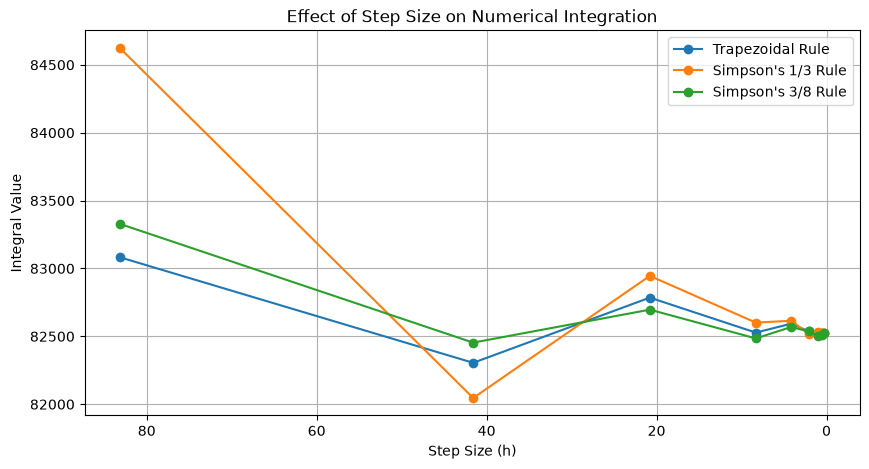

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["h"],
    results_df["Trapezoidal"],
    marker="o",
    label="Trapezoidal Rule"
)

plt.plot(
    results_df["h"],
    results_df["Simpson 1/3"],
    marker="o",
    label="Simpson's 1/3 Rule"
)

plt.plot(
    results_df["h"],
    results_df["Simpson 3/8"],
    marker="o",
    label="Simpson's 3/8 Rule"
)

plt.xlabel("Step Size (h)")
plt.ylabel("Integral Value")
plt.title("Effect of Step Size on Numerical Integration")

plt.legend()
plt.grid(True)

plt.gca().invert_xaxis()

plt.show()

In [20]:
x_original = x
y_original = y

reference_integral = np.trapezoid(
    y_original,
    x_original
)

print("Reference Integral:", reference_integral)

Reference Integral: 82525.32498931885


## Error Analysis

The reference integral is calculated using the original AAPL closing-price data and the Trapezoidal Rule.

The absolute error and percentage error of each numerical integration method are calculated with respect to this reference value.

In [21]:
results_df["Trapezoidal Error"] = abs(
    results_df["Trapezoidal"] - reference_integral
)

results_df["Simpson 1/3 Error"] = abs(
    results_df["Simpson 1/3"] - reference_integral
)

results_df["Simpson 3/8 Error"] = abs(
    results_df["Simpson 3/8"] - reference_integral
)

results_df

,n,h,Trapezoidal,Simpson 1/3,Simpson 3/8,Trapezoidal Error,Simpson 1/3 Error,Simpson 3/8 Error
0,6,83.166667,83082.613623,84624.019397,83328.513737,557.288634,2098.694408,803.188748
1,12,41.583333,82305.181943,82046.038050,82453.894629,220.143046,479.286939,71.430361
2,24,20.791667,82785.465207,82945.559629,82696.721704,260.140218,420.234639,171.396715
3,60,8.316667,82527.678640,82601.242619,82484.954114,2.353651,75.917629,40.370876
4,120,4.158333,82593.274698,82615.140050,82568.951078,67.949708,89.815061,43.626088
5,240,2.079167,82537.198146,82518.505962,82535.853300,11.873157,6.819027,10.528310
6,500,0.998000,82525.338585,82529.701235,82501.133743,0.013596,4.376246,24.191246
7,1000,0.499000,82526.794309,82527.279551,82506.587302,1.469320,1.954561,18.737687
8,2000,0.249500,82527.158293,82527.279621,82522.195720,1.833303,1.954631,3.129269


## Percentage Error

The percentage error is calculated using:

$$
\text{Percentage Error}
=
\frac{\text{Absolute Error}}
{|\text{Reference Integral}|}
\times 100
$$

In [22]:
results_df["Trapezoidal % Error"] = (
    results_df["Trapezoidal Error"]
    / abs(reference_integral)
) * 100

results_df["Simpson 1/3 % Error"] = (
    results_df["Simpson 1/3 Error"]
    / abs(reference_integral)
) * 100

results_df["Simpson 3/8 % Error"] = (
    results_df["Simpson 3/8 Error"]
    / abs(reference_integral)
) * 100

results_df

,n,h,Trapezoidal,Simpson 1/3,Simpson 3/8,Trapezoidal Error,Simpson 1/3 Error,Simpson 3/8 Error,Trapezoidal % Error,Simpson 1/3 % Error,Simpson 3/8 % Error
0,6,83.166667,83082.613623,84624.019397,83328.513737,557.288634,2098.694408,803.188748,0.675294,2.543091,0.973263
1,12,41.583333,82305.181943,82046.038050,82453.894629,220.143046,479.286939,71.430361,0.266758,0.580776,0.086556
2,24,20.791667,82785.465207,82945.559629,82696.721704,260.140218,420.234639,171.396715,0.315225,0.509219,0.207690
3,60,8.316667,82527.678640,82601.242619,82484.954114,2.353651,75.917629,40.370876,0.002852,0.091993,0.048919
4,120,4.158333,82593.274698,82615.140050,82568.951078,67.949708,89.815061,43.626088,0.082338,0.108833,0.052864
5,240,2.079167,82537.198146,82518.505962,82535.853300,11.873157,6.819027,10.528310,0.014387,0.008263,0.012758
6,500,0.998000,82525.338585,82529.701235,82501.133743,0.013596,4.376246,24.191246,0.000016,0.005303,0.029314
7,1000,0.499000,82526.794309,82527.279551,82506.587302,1.469320,1.954561,18.737687,0.001780,0.002368,0.022705
8,2000,0.249500,82527.158293,82527.279621,82522.195720,1.833303,1.954631,3.129269,0.002222,0.002369,0.003792


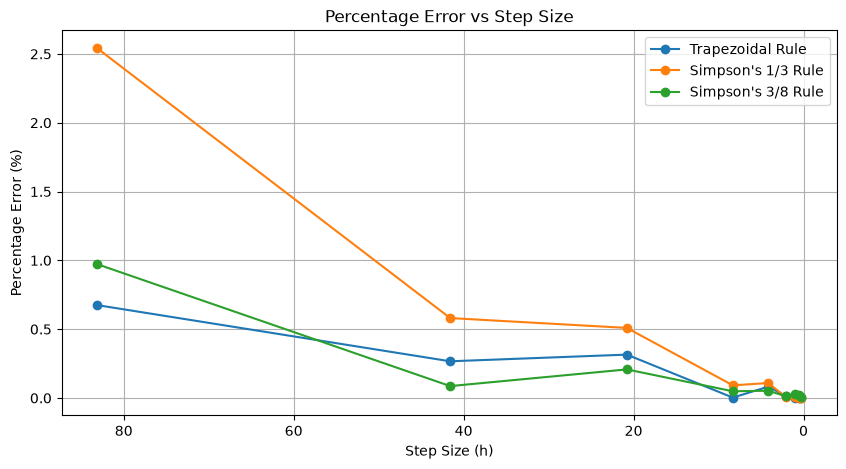

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["h"],
    results_df["Trapezoidal % Error"],
    marker="o",
    label="Trapezoidal Rule"
)

plt.plot(
    results_df["h"],
    results_df["Simpson 1/3 % Error"],
    marker="o",
    label="Simpson's 1/3 Rule"
)

plt.plot(
    results_df["h"],
    results_df["Simpson 3/8 % Error"],
    marker="o",
    label="Simpson's 3/8 Rule"
)

plt.xlabel("Step Size (h)")
plt.ylabel("Percentage Error (%)")
plt.title("Percentage Error vs Step Size")
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()

plt.show()

## Observations

1. The integral values change as the step size \(h\) is decreased, showing the effect of the number of interpolation points on numerical integration.

2. The error generally becomes smaller for finer step sizes, although the values are not strictly monotonic because the AAPL closing-price data contains fluctuations.

3. For \(n=60\), the Trapezoidal Rule gives a very small percentage error of approximately \(0.00285\%\) with respect to the reference integral.

4. Simpson's 1/3 and 3/8 rules also give small errors for finer step sizes.

5. The results show that the choice of step size has a significant effect on the numerical integration of discrete financial data.

6. Local Lagrange interpolation allows the discrete AAPL closing-price data to be evaluated at the equally spaced points required by the numerical integration rules.

## Conclusion

In this assignment, Lagrange interpolation was combined with the Trapezoidal, Simpson's 1/3, and Simpson's 3/8 numerical integration methods to estimate the integral of AAPL closing prices.

Different numbers of intervals were tested to study the effect of step size on the numerical result. The error analysis shows that finer sampling can provide more accurate integral estimates, although the convergence is affected by the fluctuations present in the financial data.

The assignment demonstrates how interpolation can be used to apply numerical integration techniques to real-world discrete data.